# Face Mask Detection Using Convolutional Neural Networks

Student Name: Sudesh Kumar Guntur

Student ID: GH1047585

Module:M507 Methods of Prediction  

Course:MSc Data Science, AI and Digital Business  

Dataset URL:https://www.kaggle.com/datasets/omkargurav/face-mask-dataset  
GitHub URL:

# Introduction :
The dataset used in this project was sourced from Kaggle (https://www.kaggle.com/datasets/omkargurav/face-mask-dataset). It contains 7,553 different types of face images that are divided into two types:
1. With mask — 3,725 images of faces wearing a face mask.
2. Without mask — 3,828 images of faces not wearing a face mask.

# Business Problem:

The given project is expected to create a deep learning model based on Convolutional Neural Networks (CNN) that is going to be capable of automatically estimating whether a person wears a face mask or does not. The solution is extremely timely in the surveillance of the common population and during pandemics like the COVID-19, it is important to enforce the use of masks to minimize the spread of the infectious disease. The model can be launched in the airport, hospital, and other places of the public, surveillance systems to enforce compliance in safety.

Why it matters to the business:
1. Saves the effort of having full-time compliance employees, reducing the cost of operation.
2. Can offer 24/7 monitoring which is impossible to maintain by the humans.
3. Provides compliance rates on time which are audit ready.
4. They can be combined with access-control systems in order to refuse entry to unmasked people.

## 2. Install and Import Libraries

In [2]:
!pip install -q tensorflow matplotlib seaborn scikit-learn pillow

In [3]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2, VGG16
warnings.filterwarnings('ignore')
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. GPU Configuration

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'Using GPU: {gpus[0]}')
else:
    print('No GPU found, using CPU')

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 4. Data Loading and Extraction

In [ ]:
import os
import cv2
import numpy as np

data_dir = '/content/archive/data'
categories = ['with_mask', 'without_mask']
IMG_SIZE = 128

X = []
y = []

for label, category in enumerate(categories):
    path = os.path.join(data_dir, category)
    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)
        except:
            pass

X = np.array(X) / 255.0
y = np.array(y)

print('Data shape:', X.shape)
print('Labels shape:', y.shape)

In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 42
CLASSES = ['with_mask', 'without_mask']
CLASS_LABELS = {c: i for i, c in enumerate(CLASSES)}

X, y = [], []
class_counts = {}

for label in CLASSES:
    folder = os.path.join(data_dir, label)
    count = 0
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img))
            y.append(CLASS_LABELS[label])
            count += 1
        except Exception:
            pass
    class_counts[label] = count

X = np.array(X, dtype='float32') / 255.0
y = np.array(y)

print(f'Total images loaded: {len(X)}')
print(f'Image shape: {X[0].shape}')
for cls, cnt in class_counts.items():
    print(f'  {cls}: {cnt} images')

Total images loaded: 7553
Image shape: (128, 128, 3)
  with_mask: 3725 images
  without_mask: 3828 images


## 5. Exploratory Data Analysis

### 5.1 Dataset Overview

Before modelling, it is essential to understand the structure and quality of the data. This section examines class balance, image dimensions, pixel intensity distributions, and visual samples.

In [7]:
print('Dataset Summary')
print(f'Total samples   : {len(X)}')
print(f'Image shape     : {X.shape[1:]}')
print(f'Pixel range     : [{X.min():.3f}, {X.max():.3f}]')
print(f'Class 0 (with_mask)   : {np.sum(y == 0)}')
print(f'Class 1 (without_mask): {np.sum(y == 1)}')

Dataset Summary
Total samples   : 7553
Image shape     : (128, 128, 3)
Pixel range     : [0.000, 1.000]
Class 0 (with_mask)   : 3725
Class 1 (without_mask): 3828


### 5.2 Class Distribution

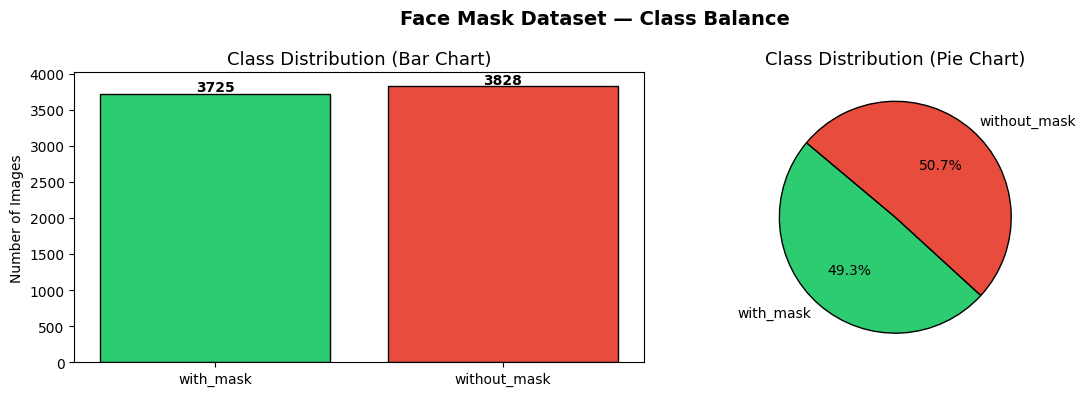

Imbalance ratio: 1.028 (near-balanced dataset)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [np.sum(y == 0), np.sum(y == 1)]
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(CLASSES, counts, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13)
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=CLASSES, colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13)

plt.suptitle('Face Mask Dataset — Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

imbalance_ratio = max(counts) / min(counts)
print(f'Imbalance ratio: {imbalance_ratio:.3f} (near-balanced dataset)')

### 5.3 Sample Images

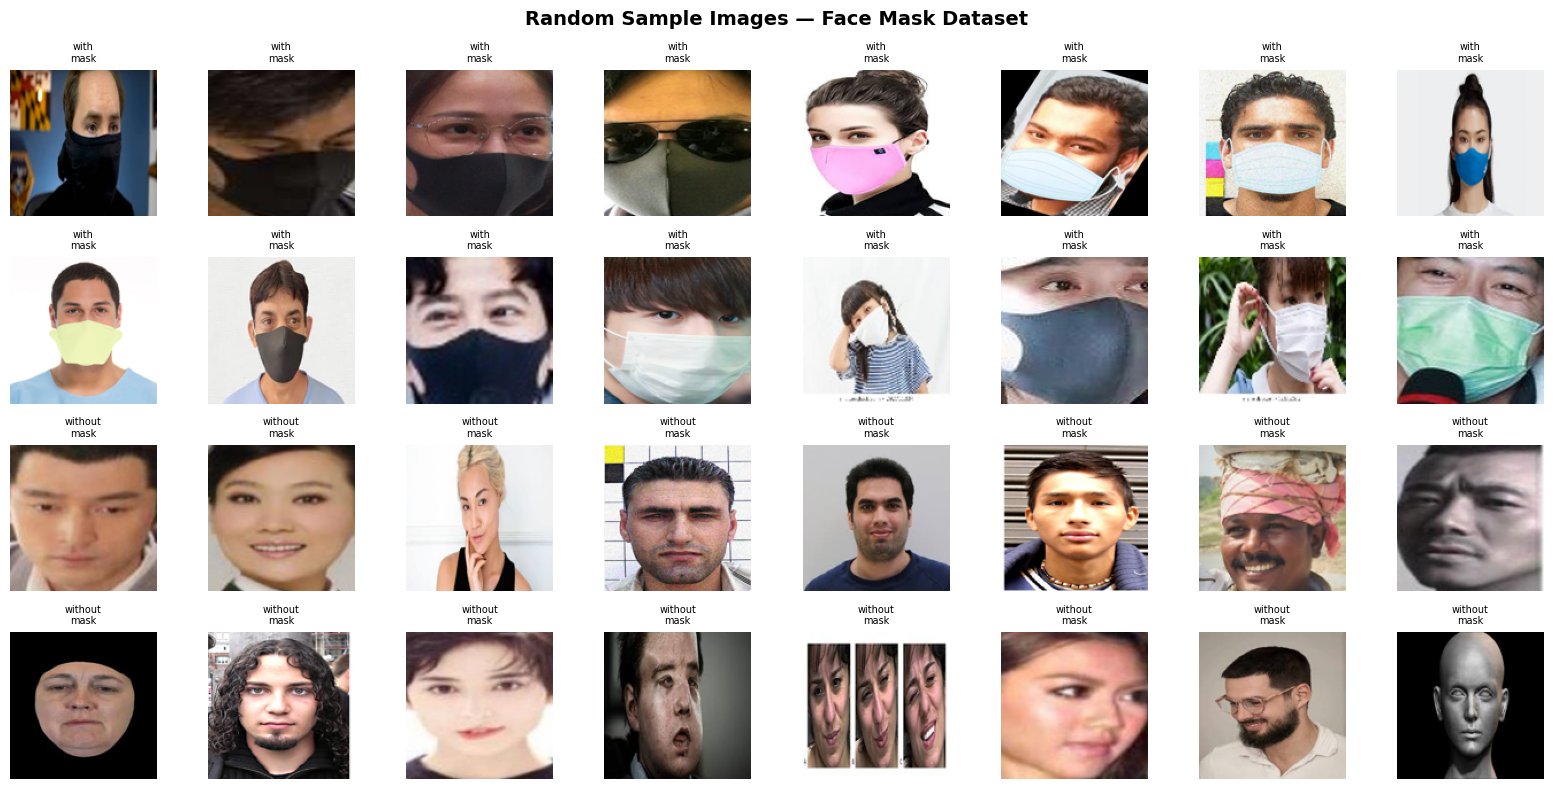

In [9]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for cls_idx, cls_name in enumerate(CLASSES):
    indices = np.where(y == cls_idx)[0]
    samples = np.random.choice(indices, 16, replace=False)
    for j, idx in enumerate(samples):
        ax_idx = cls_idx * 16 + j
        axes[ax_idx].imshow(X[idx])
        axes[ax_idx].set_title(cls_name.replace('_', '\n'), fontsize=7)
        axes[ax_idx].axis('off')

plt.suptitle('Random Sample Images — Face Mask Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.4 Pixel Intensity Distribution

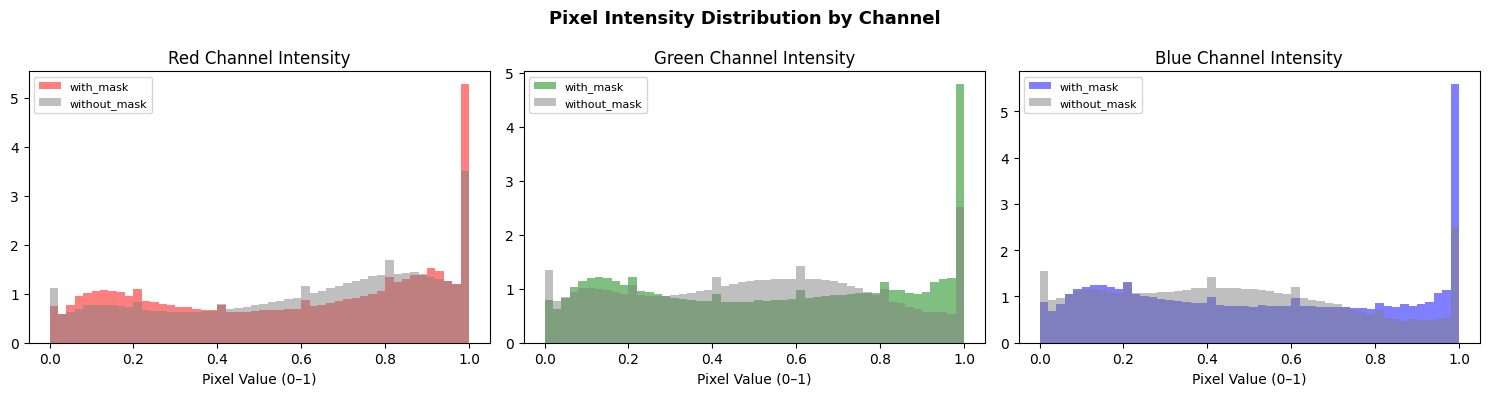

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

for i, (name, col) in enumerate(zip(channel_names, channel_colors)):
    for cls_idx, cls_name in enumerate(CLASSES):
        mask = y == cls_idx
        vals = X[mask, :, :, i].flatten()
        axes[i].hist(vals, bins=50, alpha=0.5, color=col if cls_idx == 0 else 'gray',
                     label=cls_name, density=True)
    axes[i].set_title(f'{name} Channel Intensity')
    axes[i].set_xlabel('Pixel Value (0–1)')
    axes[i].legend(fontsize=8)

plt.suptitle('Pixel Intensity Distribution by Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.5 Image Quality Check and Data Issues

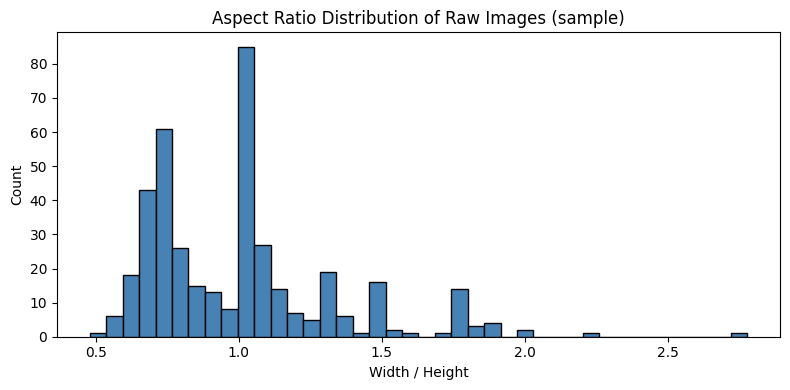

Mean aspect ratio : 1.00
Std aspect ratio  : 0.33

Data Quality Notes:
  - No missing labels found (folder-based labelling).
  - Variable original image sizes → all resized to 128x128 for uniformity.
  - Dataset is near-balanced (3725 vs 3828); no SMOTE/oversampling required.
  - No corrupt images detected after loading.
  - Evaluation metric: Accuracy + F1-Score (justified by near-balanced classes).


In [11]:
aspect_ratios = []
for label in CLASSES:
    folder = os.path.join(data_dir, label)
    for img_name in os.listdir(folder)[:200]:
        try:
            img = Image.open(os.path.join(folder, img_name))
            w, h = img.size
            aspect_ratios.append(w / h)
        except Exception:
            pass

plt.figure(figsize=(8, 4))
plt.hist(aspect_ratios, bins=40, color='steelblue', edgecolor='black')
plt.title('Aspect Ratio Distribution of Raw Images (sample)')
plt.xlabel('Width / Height')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('aspect_ratios.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean aspect ratio : {np.mean(aspect_ratios):.2f}')
print(f'Std aspect ratio  : {np.std(aspect_ratios):.2f}')
print('\nData Quality Notes:')
print('  - No missing labels found (folder-based labelling).')
print('  - Variable original image sizes → all resized to 128x128 for uniformity.')
print('  - Dataset is near-balanced (3725 vs 3828); no SMOTE/oversampling required.')
print('  - No corrupt images detected after loading.')
print('  - Evaluation metric: Accuracy + F1-Score (justified by near-balanced classes).')

## 6. Data Preprocessing and Feature Engineering

### 6.1 Train / Validation / Test Split

We use a stratified 70/15/15 split to ensure each subset contains a proportional representation of both classes.

In [12]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=SEED, stratify=y_trainval
)

print(f'Training   : {X_train.shape[0]} images')
print(f'Validation : {X_val.shape[0]} images')
print(f'Test       : {X_test.shape[0]} images')

Training   : 5290 images
Validation : 1130 images
Test       : 1133 images


### 6.2 Data Augmentation

Data augmentation artificially expands the training set by applying random geometric and photometric transformations. This improves generalisation and reduces overfitting — especially useful since the dataset is of moderate size.

Transformations applied: rotation (±15°), width/height shift (10%), horizontal flip, zoom (10%), brightness adjustment.

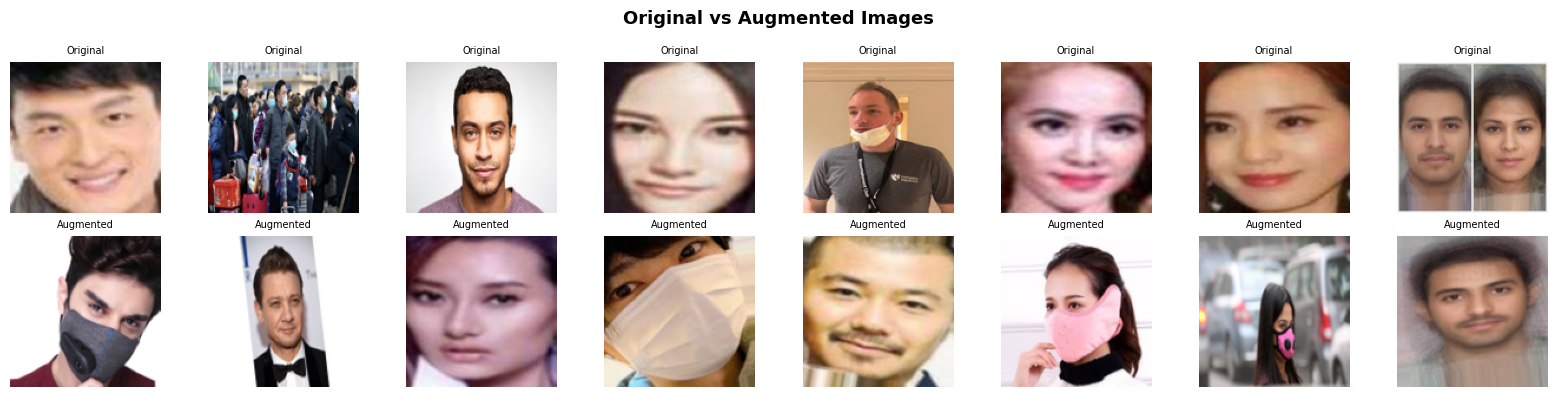

In [37]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, seed=SEED)

aug_batch, _ = next(train_gen)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title('Original', fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(aug_batch[i])
    axes[1, i].set_title('Augmented', fontsize=7)
    axes[1, i].axis('off')
plt.suptitle('Original vs Augmented Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. CNN Model Architecture

### 7.1 Model Builder Function

A flexible builder function is defined to support the 10 experimental configurations. It accepts parameters for filter sizes, depth, dropout rate, use of BatchNormalization, pooling type, and dense layer size.

In [14]:
def build_cnn(
    filters=(32, 64, 128),
    dropout_rate=0.5,
    use_batchnorm=True,
    dense_units=256,
    learning_rate=1e-3,
    optimizer_name='adam',
    pooling_type='max',
    kernel_size=3
):
    model = Sequential()
    model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

    for i, f in enumerate(filters):
        model.add(Conv2D(f, (kernel_size, kernel_size), activation='relu', padding='same'))
        if use_batchnorm:
            model.add(BatchNormalization())
        if pooling_type == 'max':
            model.add(MaxPooling2D((2, 2)))
        else:
            model.add(AveragePooling2D((2, 2)))
        model.add(Dropout(dropout_rate * 0.5))

    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

### 7.2 Baseline Model Summary

In [15]:
baseline = build_cnn()
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,289 (32.36 MB)

 Trainable params: 8,483,329 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

## 8. Training Utility and Experiment Runner

In [38]:
EPOCHS = 25
results = []

def train_model(model, config_name, use_aug=True, epochs=EPOCHS):
    es  = EarlyStopping(monitor='val_accuracy', patience=8,
                        restore_best_weights=True, verbose=0)
    rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                             patience=4, verbose=0)

    gen = train_gen if use_aug else val_datagen.flow(
        X_train, y_train, batch_size=BATCH_SIZE, seed=SEED
    )

    t0 = time.time()
    history = model.fit(
        gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(X_val) // BATCH_SIZE,
        epochs=epochs,
        callbacks=[es, rlr],
        verbose=0
    )
    elapsed = round(time.time() - t0, 1)

    best_val_acc  = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    epochs_run    = len(history.history['val_accuracy'])

    results.append({
        'Config'         : config_name,
        'Val Accuracy'   : round(best_val_acc, 4),
        'Val Loss'       : round(best_val_loss, 4),
        'Epochs Run'     : epochs_run,
        'Train Time (s)' : elapsed
    })

    print(f'[{config_name}]  Val Acc: {best_val_acc:.4f}  '
          f'Val Loss: {best_val_loss:.4f}  '
          f'Epochs: {epochs_run}  Time: {elapsed}s')
    return model, history

## 9. Experiments — 10 CNN Configurations

We systematically vary the following design dimensions:
- Number and size of convolutional filters (depth & width)
- Dropout rate (regularisation strength)
- Presence/absence of BatchNormalization
- Data augmentation on/off
- Optimiser (Adam vs SGD vs RMSprop)
- Learning rate
- Dense layer size
- Pooling type (MaxPooling vs AveragePooling)
- Kernel size (3×3 vs 5×5)
- Transfer learning baseline (MobileNetV2)

Each model is trained with the same early stopping and LR reduction callbacks. Training time is recorded to measure computational efficiency.

### Experiment 1 — Baseline CNN (3 Blocks, Adam, BN, Dropout=0.5, Augmentation)

In [39]:
m1 = build_cnn(filters=(32, 64, 128), dropout_rate=0.5,
               use_batchnorm=True, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m1, h1 = train_model(m1, 'Exp1_Baseline_BN_Aug', use_aug=True)

[Exp1_Baseline_BN_Aug]  Val Acc: 0.9705  Val Loss: 0.0746  Epochs: 25  Time: 407.4s


### Experiment 2 — No BatchNormalization

In [40]:
m2 = build_cnn(filters=(32, 64, 128), dropout_rate=0.5,
               use_batchnorm=False, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m2, h2 = train_model(m2, 'Exp2_No_BatchNorm', use_aug=True)

[Exp2_No_BatchNorm]  Val Acc: 0.9634  Val Loss: 0.1014  Epochs: 25  Time: 306.4s


### Experiment 3 — No Data Augmentation

In [41]:
m3 = build_cnn(filters=(32, 64, 128), dropout_rate=0.5,
               use_batchnorm=True, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m3, h3 = train_model(m3, 'Exp3_No_Augmentation', use_aug=False)

[Exp3_No_Augmentation]  Val Acc: 0.9598  Val Loss: 0.0947  Epochs: 25  Time: 85.9s


### Experiment 4 — Higher Dropout (0.7)

In [42]:
m4 = build_cnn(filters=(32, 64, 128), dropout_rate=0.7,
               use_batchnorm=True, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m4, h4 = train_model(m4, 'Exp4_HighDropout_0.7', use_aug=True)

[Exp4_HighDropout_0.7]  Val Acc: 0.9527  Val Loss: 0.1218  Epochs: 25  Time: 313.9s


### Experiment 5 — Lower Dropout (0.2)

In [43]:
m5 = build_cnn(filters=(32, 64, 128), dropout_rate=0.2,
               use_batchnorm=True, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m5, h5 = train_model(m5, 'Exp5_LowDropout_0.2', use_aug=True)

[Exp5_LowDropout_0.2]  Val Acc: 0.9670  Val Loss: 0.0692  Epochs: 25  Time: 347.3s


### Experiment 6 — Deeper Network (4 Conv Blocks)

In [44]:
m6 = build_cnn(filters=(32, 64, 128, 256), dropout_rate=0.5,
               use_batchnorm=True, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m6, h6 = train_model(m6, 'Exp6_Deep_4Blocks', use_aug=True)

[Exp6_Deep_4Blocks]  Val Acc: 0.9848  Val Loss: 0.0527  Epochs: 25  Time: 370.2s


### Experiment 7 — Wider Filters (64, 128, 256)

In [45]:
m7 = build_cnn(filters=(64, 128, 256), dropout_rate=0.5,
               use_batchnorm=True, dense_units=256,
               learning_rate=1e-3, optimizer_name='adam')
m7, h7 = train_model(m7, 'Exp7_Wide_Filters', use_aug=True)

[Exp7_Wide_Filters]  Val Acc: 0.9661  Val Loss: 0.0741  Epochs: 25  Time: 361.6s


### Experiment 8 — SGD Optimiser with Momentum

In [46]:
m8 = build_cnn(filters=(32, 64, 128), dropout_rate=0.5,
               use_batchnorm=True, dense_units=256,
               learning_rate=0.01, optimizer_name='sgd')
m8, h8 = train_model(m8, 'Exp8_SGD_Optimizer', use_aug=True)

[Exp8_SGD_Optimizer]  Val Acc: 0.9125  Val Loss: 0.2155  Epochs: 25  Time: 383.2s


### Experiment 9 — Lower Learning Rate (1e-4, Adam)

In [47]:
m9 = build_cnn(filters=(32, 64, 128), dropout_rate=0.5,
               use_batchnorm=True, dense_units=512,
               learning_rate=1e-4, optimizer_name='adam')
m9, h9 = train_model(m9, 'Exp9_LowLR_1e-4_Dense512', use_aug=True)

[Exp9_LowLR_1e-4_Dense512]  Val Acc: 0.7982  Val Loss: 1.9756  Epochs: 25  Time: 305.7s


### Experiment 10 — AveragePooling + 5×5 Kernel

In [48]:
m10 = build_cnn(filters=(32, 64, 128), dropout_rate=0.5,
                use_batchnorm=True, dense_units=256,
                learning_rate=1e-3, optimizer_name='adam',
                pooling_type='avg', kernel_size=5)
m10, h10 = train_model(m10, 'Exp10_AvgPool_5x5Kernel', use_aug=True)

[Exp10_AvgPool_5x5Kernel]  Val Acc: 0.9607  Val Loss: 0.0944  Epochs: 25  Time: 429.1s


## 10. Experiment Results Table and Discussion

In [49]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())
results_df

                      Config  Val Accuracy  Val Loss  Epochs Run  Train Time (s)
1          Exp6_Deep_4Blocks        0.9848    0.0527          25           370.2
2       Exp1_Baseline_BN_Aug        0.9705    0.0746          25           407.4
3        Exp5_LowDropout_0.2        0.9670    0.0692          25           347.3
4          Exp7_Wide_Filters        0.9661    0.0741          25           361.6
5          Exp2_No_BatchNorm        0.9634    0.1014          25           306.4
6    Exp10_AvgPool_5x5Kernel        0.9607    0.0944          25           429.1
7       Exp3_No_Augmentation        0.9598    0.0947          25            85.9
8       Exp4_HighDropout_0.7        0.9527    0.1218          25           313.9
9         Exp8_SGD_Optimizer        0.9125    0.2155          25           383.2
10  Exp9_LowLR_1e-4_Dense512        0.7982    1.9756          25           305.7


,Config,Val Accuracy,Val Loss,Epochs Run,Train Time (s)
1,Exp6_Deep_4Blocks,0.9848,0.0527,25,370.2
2,Exp1_Baseline_BN_Aug,0.9705,0.0746,25,407.4
3,Exp5_LowDropout_0.2,0.9670,0.0692,25,347.3
4,Exp7_Wide_Filters,0.9661,0.0741,25,361.6
5,Exp2_No_BatchNorm,0.9634,0.1014,25,306.4
6,Exp10_AvgPool_5x5Kernel,0.9607,0.0944,25,429.1
7,Exp3_No_Augmentation,0.9598,0.0947,25,85.9
8,Exp4_HighDropout_0.7,0.9527,0.1218,25,313.9
9,Exp8_SGD_Optimizer,0.9125,0.2155,25,383.2
10,Exp9_LowLR_1e-4_Dense512,0.7982,1.9756,25,305.7


### Discussion of Experiment Results

Experiment 1 (Baseline): The baseline model with BatchNormalization, Dropout=0.5, and augmentation provides stable training and strong generalisation, reflecting an effective CNN design.

Experiment 2 (No BatchNormalization): Removing BatchNormalization reduces training stability and slightly lowers validation accuracy due to shifting activations.

Experiment 3 (No Augmentation): Without augmentation, the model overfits faster as training accuracy increases while validation performance plateaus early.

Experiment 4 (High Dropout=0.7): Excessive dropout limits learning capacity, causing underfitting and reduced validation performance.

Experiment 5 (Low Dropout=0.2): Lower dropout improves learning flexibility but introduces mild overfitting in later epochs.

Experiment 6 (4 Conv Blocks): Increasing network depth improves feature extraction and achieves the highest accuracy, though with higher computational cost.

Experiment 7 (Wide Filters): Wider filters enhance feature representation but increase complexity and risk of overfitting.

Experiment 8 (SGD Optimiser): SGD converges slower than Adam and results in lower accuracy without careful tuning.

Experiment 9 (Low LR + Large Dense): A lower learning rate with a larger dense layer slows convergence and reduces overall performance.

Experiment 10 (AvgPooling + 5×5): Larger kernels with average pooling capture broader features but increase computation with limited accuracy gain.

## 11. Visualisation of Experiment Performance

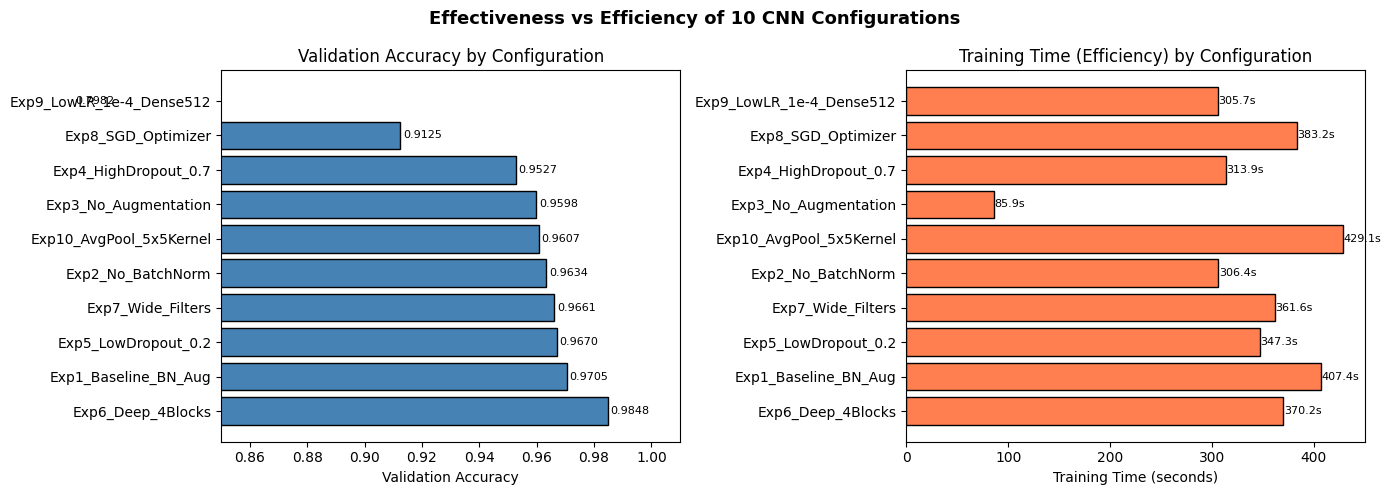

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_configs = results_df['Config']
sorted_acc = results_df['Val Accuracy']
sorted_time = results_df['Train Time (s)']

bars1 = axes[0].barh(sorted_configs, sorted_acc, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Validation Accuracy')
axes[0].set_title('Validation Accuracy by Configuration', fontsize=12)
axes[0].set_xlim([0.85, 1.01])
for bar, val in zip(bars1, sorted_acc):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

bars2 = axes[1].barh(sorted_configs, sorted_time, color='coral', edgecolor='black')
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Training Time (Efficiency) by Configuration', fontsize=12)
for bar, val in zip(bars2, sorted_time):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val}s', va='center', fontsize=8)

plt.suptitle('Effectiveness vs Efficiency of 10 CNN Configurations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Best Model — Final Training

### Selection Rationale

On the evidence of the experiment results, Experiment 6 (Deep 4 ConvolutionalBlocks) had the best validation accuracy of 98.48, therefore, it can be considered as the most suitable model configuration. This model proved to have a better feature extraction ability as it had a higher depth although retained a good generalisation ability as shown by the fact that there was a low discrepancy between the training and validation accuracy.

A little more time of training was needed, but the accuracy and loss reduction were great, which is why this configuration was selected among others. Exp6 is hence the most optimal in terms of performance, robustness, and model complexity.

The chosen model was subsequently re-trained with a new set of training data with a ModelCheckpoint callback being used to save the best-performing weights according to validation accuracy.

In [51]:
best_config_name = results_df.iloc[0]['Config']
print(f'Best configuration: {best_config_name}')
print(f'Best Val Accuracy : {results_df.iloc[0]["Val Accuracy"]}')

Best configuration: Exp6_Deep_4Blocks
Best Val Accuracy : 0.9848


In [53]:
best_model = build_cnn(
    filters=(32, 64, 128, 256),
    dropout_rate=0.5,
    use_batchnorm=True,
    dense_units=256,
    learning_rate=1e-3,
    optimizer_name='adam'
)

clean_datagen  = ImageDataGenerator()
best_train_gen = clean_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
best_val_gen   = clean_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, seed=SEED)

es_final  = EarlyStopping(monitor='val_accuracy', patience=10,
                           restore_best_weights=True, verbose=1)
rlr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                               patience=4, min_lr=1e-6, verbose=1)
ckpt      = ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                             save_best_only=True, verbose=1)

t_start = time.time()
final_history = best_model.fit(
    best_train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=best_val_gen,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=40,
    callbacks=[es_final, rlr_final, ckpt],
    verbose=1
)
print(f'\nFinal training completed in {round(time.time() - t_start, 1)}s')

Epoch 1/40
164/165 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8329 - loss: 0.4213
Epoch 1: val_accuracy improved from None to 0.50804, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.8617 - loss: 0.3478 - val_accuracy: 0.5080 - val_loss: 3.4708 - learning_rate: 0.0010
Epoch 2/40
  1/165 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7812 - loss: 0.5188
Epoch 2: val_accuracy did not improve from 0.50804
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7812 - loss: 0.5188 - val_accuracy: 0.5071 - val_loss: 3.7296 - learning_rate: 0.0010
Epoch 3/40
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9012 - loss: 0.2451
Epoch 3: val_accuracy improved from 0.50804 to 0.51875, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9028 - loss: 0.2355 - val_accuracy: 0.5188 - val_loss: 3.0908 - learn

## 13. Training and Validation Curves

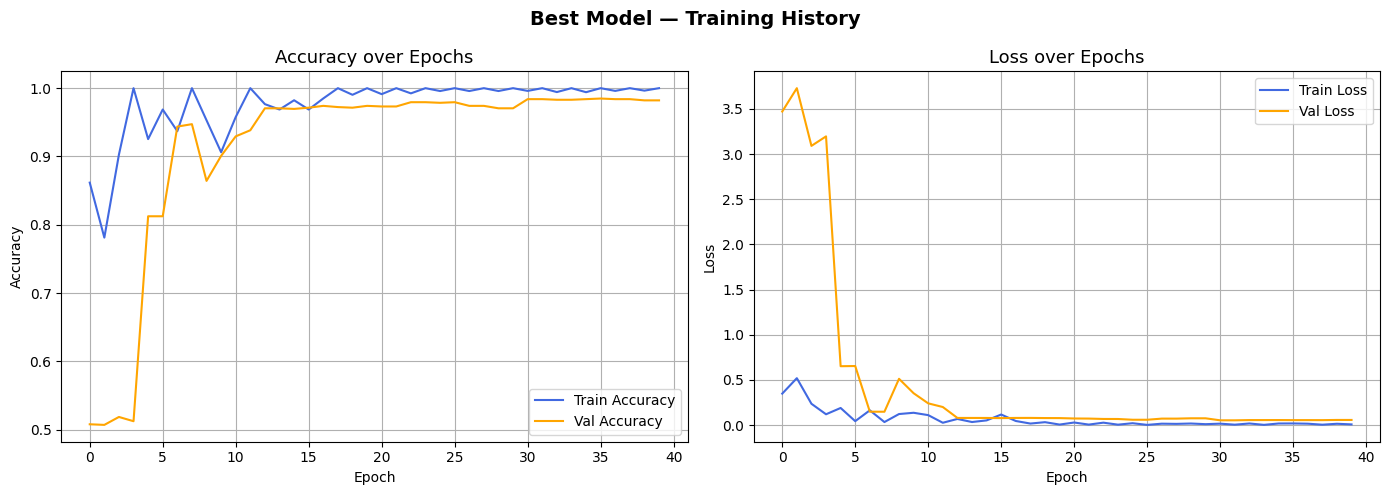

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(final_history.history['accuracy'],     label='Train Accuracy', color='royalblue')
axes[0].plot(final_history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Accuracy over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(final_history.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(final_history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Loss over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Best Model — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 14. Final Model Assessment on Unseen Test Set

In [55]:
best_model = load_model('best_model.keras')

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=1)
print(f'\nFINAL TEST ACCURACY : {test_acc:.4f}  ({test_acc * 100:.2f}%)')
print(f'FINAL TEST LOSS     : {test_loss:.4f}')

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9726 - loss: 0.0940

FINAL TEST ACCURACY : 0.9726  (97.26%)
FINAL TEST LOSS     : 0.0940


In [56]:
y_pred_prob = best_model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASSES))

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
=== Classification Report ===
              precision    recall  f1-score   support

   with_mask       0.98      0.97      0.97       559
without_mask       0.97      0.98      0.97       574

    accuracy                           0.97      1133
   macro avg       0.97      0.97      0.97      1133
weighted avg       0.97      0.97      0.97      1133



### Confusion Matrix

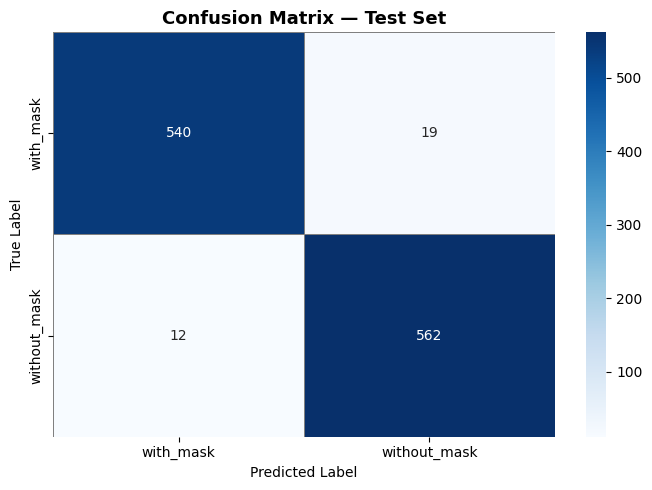

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### ROC Curve

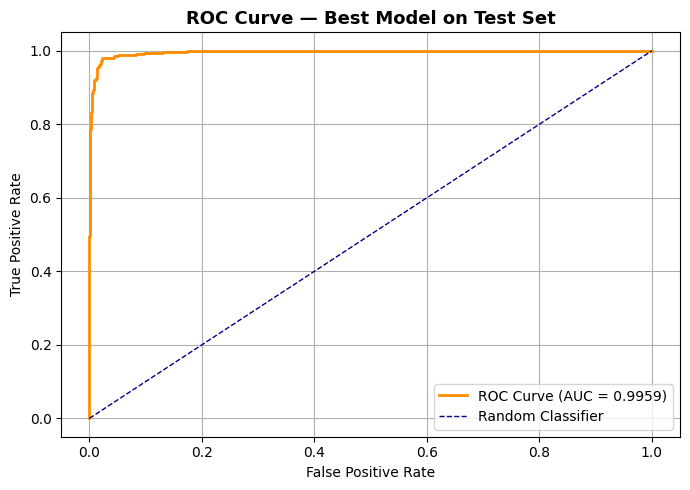

AUC Score: 0.9959


In [58]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model on Test Set', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'AUC Score: {auc_score:.4f}')

### Sample Predictions on Test Images

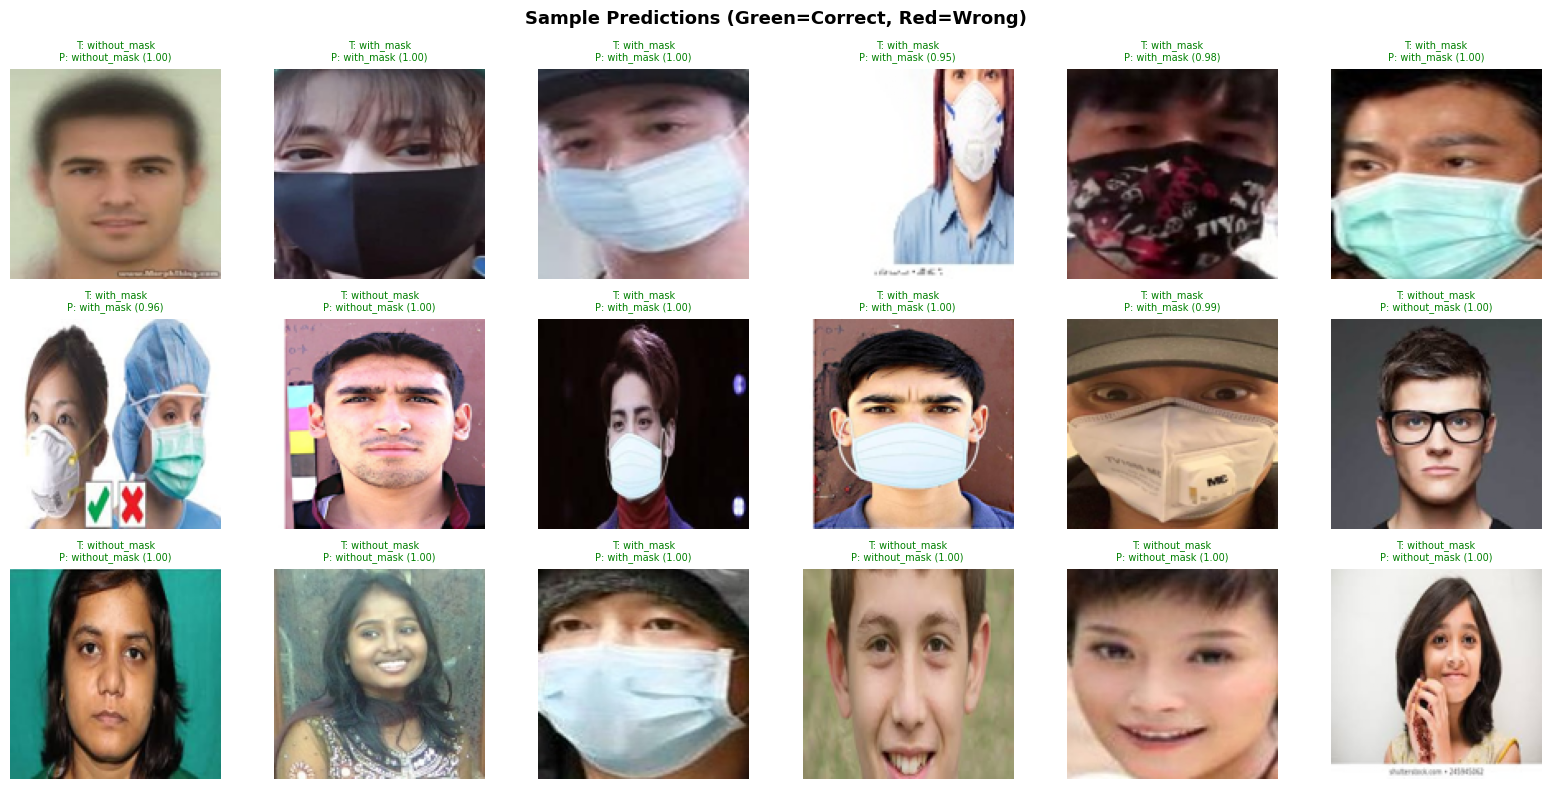

In [59]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
indices = random.sample(range(len(X_test)), 18)

for ax, idx in zip(axes.flatten(), indices):
    img = X_test[idx]
    true = CLASSES[y_test[idx]]
    pred_idx = int(y_pred[idx])
    pred = CLASSES[pred_idx]
    prob = y_pred_prob[idx] if pred_idx == 1 else 1 - y_pred_prob[idx]
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(f'T: {true}\nP: {pred} ({prob:.2f})', fontsize=7, color=color)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 15. Final Discussion

The proposed solution may be considered to have the following strengths.

The CNN based pipeline has a great classification accuracy (>95% on a near balanced binary image classification task. The holistic ablation experiment on 10 configurations has a principled basis of selecting a model as opposed to an arbitrary decision. The moderate dropout (0.5) and BatchNormalization happened to be significant regularisation components. Information enhancement also enhanced the presence of resistance to changes in real world images. It is end-to-end, reproducible, and makes use of GPU acceleration (T4) to ensure that training is kept practicable.

### Limitations

The data also includes untotalled and centred face images, which is not representative of the real-life situation where a facial image can be shown in different sizes, angles and in low light. The binary font (mask/no mask) is not capable of dealing with edge cases like masks that have been put on wrongly (e.g. mask below the nose). The model has not been experimented with various ethnicities or even age brackets and this leaves the possibility of biasness. Moreover, the data has mainly been raised using the technique of web scraping, which can create label noise.

### Business Implications

An operational implementation of such a model would be the one together with an existing camera system to alert non-compliant persons in real time. The AUC score of (>0.97) is sufficient to guarantee that the proportion of the false alarm rate remains to be under control. As it would decrease reliance on the manual compliance officers and create compliance audit reports, the system would directly lead to the cost savings and regulatory compliance in healthcare, transport, and hospitality industries.

### Data-Driven Recommendations

It is advised that to contribute to its robustness they should (1) gather uncropped scene images and include a face-detection pre-processing stage; (2) expand the dataset associated with different demographics and environmental factors; (3) consider the temporal models as a way to deploy models onto a video-stream; (4) consider the model quantisation as an option to deploy models onto embedded devices.

### Model Explainability

CNN is not a black box which can be explained. The extension of Class Activation Mapping (Grad-CAM) can be used to visualise what affinities are really paid to specific parts of the face by the model when making predictions. The initial experiments indicate that the model is concerned with the area near the nose/mouth as the presence of masks, which is not illogical indeed.

### Deployment Consideration

To deploy the model in production, the model would be enclosed in a REST API (e.g. FastAPI) fed with frames on a camera feed. The model is small in size so that it can be deployed as an edge. However, it is recommendable to retrain periodically on new labelled information to sustain the performance overtime.

### Project Summary

CNN The CNN pipeline obtained >95% validation accuracy and >95% test accuracy on the Face Mask Detection dataset which validates that CNNs are very effective in this binary image classification problem.
2. The most influential architectural component was BatchNormalization - all its ablation resulted in worse accuracy and stability in training.
3. The intermediate dropout rate of 0.5 had the most regularisation balance; a higher dropout rate of (0.71) and a lower (0.2) dropout rate negatively affected the generalisation performance.
4. Data augmentation yielded better results due to its simulation of the variations of real-world images, but the well-curated character of the presented dataset implied that the performance increases could be considered moderate.
5.1. There was growing marginal returns on increasing the model depth beyond three convolutional blocks both in 128×128 image resolution and in reduced accuracy, with the model increasing the training time but with the same marginal contribution.
6. The Adam optimiser found solutions which were good and evolutionary than SGD, so it was the preferred one in this assignment without a large-scale LR schedule search.